# 🎓 Tutorial: Data Handling & Preprocessing for Machine Learning

Notebook ini dibuat berdasarkan materi **"Sesi 2: Data Handling and Preprocessing"** oleh Ruby Thalib (AI & Data Consultant, rubythalib.ai).

Tujuannya: mengenalkan konsep-konsep inti tentang bagaimana data dipersiapkan sebelum digunakan untuk membuat model Machine Learning — dengan cara yang sederhana dan bisa langsung dicoba, meskipun kamu belum punya banyak latar belakang teknis.

**Yang akan kita pelajari:**
1. Menangani Missing Values (data yang hilang/kosong)
2. Mendeteksi & Menangani Outlier (data yang aneh/ekstrem)
3. Feature Engineering — mengubah kategori jadi angka
4. Text Preprocessing — mengubah teks jadi angka (Bag of Words & TF-IDF)
5. Mengurangi Dimensi Data (PCA)
6. Konsep Data Versioning

> 💡 **Cara pakai:** Klik `Runtime` → `Run all` di Google Colab, atau jalankan setiap sel satu per satu dengan menekan `Shift + Enter`. Semua library yang dipakai di sini sudah tersedia otomatis di Google Colab, jadi tidak perlu instalasi tambahan.

## 🔧 0. Persiapan

Jalankan sel di bawah ini terlebih dahulu untuk memuat semua tools yang kita butuhkan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

print("Semua library berhasil dimuat! Siap lanjut ✅")

Semua library berhasil dimuat! Siap lanjut ✅


## 📦 1. Data Collection & Storage (Konsep Singkat)

Sebelum masuk ke praktik, ada dua jenis data yang perlu kamu kenal:

- **Unstructured Data** — data yang "bentuknya bebas", misalnya gambar, teks, audio. Manusia bisa langsung memahami maknanya tanpa struktur khusus (contoh: kita bisa langsung mengenali gambar kucing).
- **Structured Data** — data yang rapi dalam bentuk tabel/baris-kolom, misalnya data transaksi atau data pelanggan. Maknanya sangat tergantung konteks bisnis, sehingga tidak selalu bisa dipahami "sekilas lihat" oleh orang awam.

Kedua jenis data ini butuh tempat penyimpanan yang **aman, mudah diakses, dan bisa di-versioning** (disimpan riwayat perubahannya) — ini akan kita bahas lebih lanjut di bagian akhir notebook.

## 🕳️ 2. Menangani Missing Values

Data di dunia nyata jarang yang sempurna — sering ada nilai yang kosong (`NaN`). Ada dua pendekatan umum:

1. **Dropna** — membuang baris/kolom yang datanya kosong (cocok jika datanya sedikit yang hilang).
2. **Fillna** — mengisi nilai kosong dengan nilai pengganti, misalnya rata-rata (mean), nilai tengah (median), atau nilai yang paling sering muncul (mode).

Mari kita coba dengan contoh data sederhana.

In [2]:
sample_data = pd.read_csv('../data/customers-10000.csv')  # diubah dari link Google Drive pribadi ke path lokal repo ini (isi dataset identik)

In [3]:
sample_data.head()

,Index,Customer Id,First Name,Last Name,Company,City,Country,Phone 1,Phone 2,Email,Subscription Date,Website
0,1,EB54EF1154C3A78,Heather,Callahan,Mosley-David,Lake Jeffborough,Norway,043-797-5229,915.112.1727,urangel@espinoza-francis.net,2020-08-26,http://www.escobar.org/
1,2,10dAcafEBbA5FcA,Kristina,Ferrell,"Horn, Shepard and Watson",Aaronville,Andorra,932-062-1802,(209)172-7124x3651,xreese@hall-donovan.com,2020-04-27,https://tyler-pugh.info/
2,3,67DAB15Ebe4BE4a,Briana,Andersen,Irwin-Oneal,East Jordan,Nepal,8352752061,(567)135-1918,haleybraun@blevins-sexton.com,2022-03-22,https://www.mack-bell.net/
3,4,6d350C5E5eDB4EE,Patty,Ponce,Richardson Group,East Kristintown,Northern Mariana Islands,302.398.3833,196-189-7767x770,hohailey@anthony.com,2020-07-02,https://delacruz-freeman.org/
4,5,5820deAdCF23EFe,Kathleen,Mccormick,Carson-Burch,Andresmouth,Macao,001-184-153-9683x1497,552.051.2979x342,alvaradojesse@rangel-shields.com,2021-01-17,https://welch.info/


In [4]:
# Membuat contoh data dengan missing values
data = {
    'nama': ['Andi', 'Budi', 'Citra', 'Dewi', 'Eka'],
    'umur': [25, np.nan, 30, 22, np.nan],
    'gaji': [5000000, 6000000, np.nan, 4500000, 5200000]
}
df = pd.DataFrame(data)

df

,nama,umur,gaji
0,Andi,25.0,5000000.0
1,Budi,NaN,6000000.0
2,Citra,30.0,NaN
3,Dewi,22.0,4500000.0
4,Eka,NaN,5200000.0


In [5]:
print("Data asli (perhatikan ada nilai NaN / kosong):")
print(df)

print("\nJumlah missing value per kolom:")
print(df.isnull().sum())
print()
print(df.isnull().sum() / len(df) * 100)

Data asli (perhatikan ada nilai NaN / kosong):
    nama  umur       gaji
0   Andi  25.0  5000000.0
1   Budi   NaN  6000000.0
2  Citra  30.0        NaN
3   Dewi  22.0  4500000.0
4    Eka   NaN  5200000.0

Jumlah missing value per kolom:
nama    0
umur    2
gaji    1
dtype: int64

nama     0.0
umur    40.0
gaji    20.0
dtype: float64


In [6]:
print("\nJumlah missing value per kolom:")
print(sample_data.isnull().sum())


Jumlah missing value per kolom:
Index                0
Customer Id          0
First Name           0
Last Name            0
Company              0
City                 0
Country              0
Phone 1              0
Phone 2              0
Email                0
Subscription Date    0
Website              0
dtype: int64


In [7]:
# Opsi 1: Membuang baris yang punya data kosong
df_dropped = df.dropna()
print("Setelah dropna():")
print(df_dropped)


Setelah dropna():
   nama  umur       gaji
0  Andi  25.0  5000000.0
3  Dewi  22.0  4500000.0


In [8]:
# Opsi 2: Mengisi data kosong dengan mean / median
df_filled = df.copy()
df_filled['umur'] = df_filled['umur'].fillna(df_filled['umur'].mean())
df_filled['gaji'] = df_filled['gaji'].fillna(df_filled['gaji'].median())

print("\nSetelah fillna() dengan mean/median:")
print(df_filled)


Setelah fillna() dengan mean/median:
    nama       umur       gaji
0   Andi  25.000000  5000000.0
1   Budi  25.666667  6000000.0
2  Citra  30.000000  5100000.0
3   Dewi  22.000000  4500000.0
4    Eka  25.666667  5200000.0


## 📊 3. Mendeteksi & Menangani Outlier

Outlier adalah data yang nilainya jauh berbeda dari mayoritas data lainnya. Sesuai materi slide:

- Jika outlier **jarang terjadi dan tidak berdampak ke bisnis** → boleh dibuang.
- Jika outlier **mengganggu proses bisnis** → jangan dibuang, tapi ditangani (di dunia production, salah satu caranya adalah pakai *Autoencoder* — teknik yang lebih lanjut yang melatih model untuk mengenali pola data normal, sehingga data di luar pola tersebut punya error yang besar dan bisa dideteksi sebagai outlier).

Untuk pemula, kita akan pakai cara yang lebih sederhana dan sangat umum dipakai: **metode IQR (Interquartile Range)**.

In [9]:
# Membuat contoh data gaji, dengan 1 outlier yang sangat besar
np.random.seed(42)
gaji = np.random.normal(5000000, 1000000, 1000).tolist()
gaji.append(50000000)  # outlier: gaji yang jauh lebih besar dari yang lain
df_gaji = pd.DataFrame({'gaji': gaji})

df_gaji.head()

,gaji
0,5.496714e+06
1,4.861736e+06
2,5.647689e+06
3,6.523030e+06
4,4.765847e+06


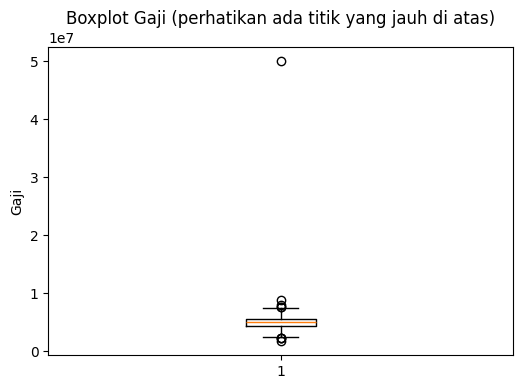

In [10]:
plt.figure(figsize=(6, 4))
plt.boxplot(df_gaji['gaji'])
plt.title('Boxplot Gaji (perhatikan ada titik yang jauh di atas)')
plt.ylabel('Gaji')
plt.show()

In [11]:
# Deteksi outlier dengan metode IQR
Q1 = df_gaji['gaji'].quantile(0.25)
Q3 = df_gaji['gaji'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outliers = df_gaji[(df_gaji['gaji'] < batas_bawah) | (df_gaji['gaji'] > batas_atas)]
print("Outlier yang terdeteksi:")
outliers.head()


Outlier yang terdeteksi:


,gaji
74,2.380255e+06
179,7.720169e+06
209,8.852731e+06
262,1.758733e+06
478,8.078881e+06


In [12]:
len(outliers), len(df_gaji)

(9, 1001)

In [13]:
df_bersih = df_gaji[(df_gaji['gaji'] >= batas_bawah) & (df_gaji['gaji'] <= batas_atas)]
print(f"\nJumlah data sebelum: {len(df_gaji)} baris")
print(f"Jumlah data setelah outlier dibuang: {len(df_bersih)} baris")


Jumlah data sebelum: 1001 baris
Jumlah data setelah outlier dibuang: 992 baris


## 🏷️ 4. Feature Engineering — Mengubah Kategori Jadi Angka

Model Machine Learning hanya mengerti **angka**, bukan teks kategori seperti "Apple" atau "Chicken". Maka dari itu kita perlu mengubahnya. Dua cara paling umum (persis seperti contoh di slide):

- **Label Encoding** — setiap kategori diberi 1 angka unik (misalnya Apple = 1, Chicken = 2).
- **One Hot Encoding** — setiap kategori dibuat jadi kolom sendiri berisi 0/1.

⚠️ Catatan: Label Encoding cocok untuk kategori yang punya urutan/tingkatan (misalnya "rendah, sedang, tinggi"). Untuk kategori yang tidak punya urutan seperti nama makanan, **One Hot Encoding biasanya lebih aman.**

In [14]:
# Data contoh, sama seperti di slide
food = pd.DataFrame({
    'Food Name': ['Apple', 'Chicken', 'Broccoli'],
    'Calories': [95, 231, 50]
})
print("Data asli:")
print(food)



Data asli:
  Food Name  Calories
0     Apple        95
1   Chicken       231
2  Broccoli        50


In [15]:
# --- Label Encoding ---
le = LabelEncoder()
food_label = food.copy()
food_label['Categorical #'] = le.fit_transform(food_label['Food Name'])
print("\nSetelah Label Encoding:")
print(food_label)


Setelah Label Encoding:
  Food Name  Calories  Categorical #
0     Apple        95              0
1   Chicken       231              2
2  Broccoli        50              1


In [16]:
# --- One Hot Encoding ---
food_onehot = pd.get_dummies(food, columns=['Food Name'])
# ubah True/False jadi 1/0 supaya persis seperti di slide
food_onehot = food_onehot.astype({col: int for col in food_onehot.columns if col != 'Calories'})
print("Setelah One Hot Encoding:")
print(food_onehot)

Setelah One Hot Encoding:
   Calories  Food Name_Apple  Food Name_Broccoli  Food Name_Chicken
0        95                1                   0                  0
1       231                0                   0                  1
2        50                0                   1                  0


## 📝 5. Text Preprocessing — Mengubah Teks Jadi Angka

Sama seperti kategori, teks juga perlu diubah menjadi vektor angka (proses ini disebut *vektorisasi*). Kita akan coba dua metode paling dasar dan paling sering dipakai, memakai contoh korpus yang sama persis dengan yang ada di slide:

- d1 = "rumah ini bagus" *(the house is nice)*
- d2 = "rumah saya makan nasi" *(my house, I eat rice)*
- d3 = "saya makan nasi" *(I eat rice)*

### Bag of Words (BoW)
Menghitung **berapa kali** tiap kata muncul di setiap kalimat/dokumen.

In [17]:
corpus = [
    "rumah ini bagus",        # d1
    "rumah saya makan nasi",  # d2
    "saya makan nasi"         # d3
]

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus)

print("Kosakata (corpus):", list(vectorizer.get_feature_names_out()))
print("\nBag of Words matrix:")
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=['d1', 'd2', 'd3']
)
print(bow_df)

Kosakata (corpus): ['bagus', 'ini', 'makan', 'nasi', 'rumah', 'saya']

Bag of Words matrix:
    bagus  ini  makan  nasi  rumah  saya
d1      1    1      0     0      1     0
d2      0    0      1     1      1     1
d3      0    0      1     1      0     1


In [18]:
bow_df.iloc[0]

bagus    1
ini      1
makan    0
nasi     0
rumah    1
saya     0
Name: d1, dtype: int64

### TF-IDF (Term Frequency - Inverse Document Frequency)

BoW punya kelemahan: kata yang sering muncul di **semua** dokumen (misalnya "dan", "yang") dianggap penting padahal sebenarnya kurang informatif. TF-IDF memperbaiki ini — kata yang muncul di banyak dokumen akan diberi **nilai lebih rendah**, sedangkan kata yang unik/jarang akan diberi **nilai lebih tinggi**.

In [19]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print("TF-IDF matrix (semakin besar angkanya, semakin 'khas' kata itu untuk dokumen tsb):")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=['d1', 'd2', 'd3']
).round(3)
print(tfidf_df)

TF-IDF matrix (semakin besar angkanya, semakin 'khas' kata itu untuk dokumen tsb):
    bagus    ini  makan   nasi  rumah   saya
d1  0.623  0.623  0.000  0.000  0.474  0.000
d2  0.000  0.000  0.500  0.500  0.500  0.500
d3  0.000  0.000  0.577  0.577  0.000  0.577


> 💡 **Bonus info (tanpa perlu coding dulu):** Ada juga metode yang lebih canggih bernama **Word2Vec**, yaitu sebuah neural network kecil yang belajar makna kata dari kata-kata di sekitarnya (bukan sekadar frekuensi kemunculan). Hasilnya, kata-kata dengan makna mirip akan punya posisi vektor yang berdekatan — misalnya vektor "Raja" dan "Ratu" akan berdekatan dalam satu dimensi tertentu (kekuasaan). Ini topik lanjutan yang bisa kamu pelajari setelah menguasai BoW dan TF-IDF.

## 📉 6. Mengurangi Dimensi Data (PCA)

Kadang data punya terlalu banyak kolom/fitur, sehingga sulit divisualisasikan atau justru membuat model jadi lambat dan bingung. **PCA (Principal Component Analysis)** adalah teknik untuk memampatkan data ke dimensi yang lebih kecil, sambil tetap menjaga informasi yang paling penting.

Kita coba dengan dataset bunga Iris (4 fitur) yang kita mampatkan jadi 2 dimensi supaya bisa divisualisasikan.

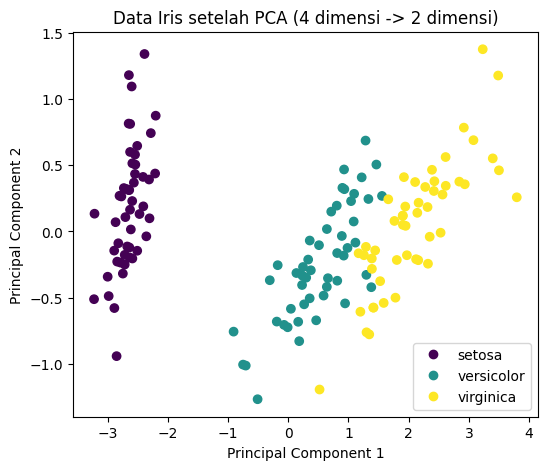

Dimensi awal: 4 fitur
Dimensi setelah PCA: 2 fitur
Informasi yang berhasil dijaga: 97.8%


In [20]:
iris = load_iris()
X = iris.data   # 4 fitur: panjang & lebar kelopak/mahkota bunga
y = iris.target # jenis bunga

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Data Iris setelah PCA (4 dimensi -> 2 dimensi)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

print(f"Dimensi awal: {X.shape[1]} fitur")
print(f"Dimensi setelah PCA: {X_pca.shape[1]} fitur")
print(f"Informasi yang berhasil dijaga: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [21]:
# iris

## 🗂️ 7. Konsep Data Versioning

Bayangkan kamu sedang mengerjakan dokumen penting dan menyimpannya dengan nama `laporan_v1`, lalu `laporan_v2` setelah direvisi — supaya kalau versi baru ternyata salah, kamu masih bisa kembali ke versi lama. **Data versioning** menerapkan ide yang sama untuk dataset.

Kenapa ini penting untuk Machine Learning?
- Kalau model tiba-tiba jadi lebih buruk setelah update data, kita bisa **rollback** ke versi data sebelumnya.
- Proses pengembangan model jadi lebih **tertrack** (mudah dilacak riwayatnya).

Beberapa contoh tools yang biasa dipakai di dunia nyata untuk ini:
- **DVC** dan **GitLab** — untuk versioning dataset
- **CVAT, Roboflow, SuperAnnotate** — untuk anotasi data sekaligus versioning
- **MLflow, Neptune.ai, W&B** — untuk melacak eksperimen model

Di bawah ini kita simulasikan idenya secara sangat sederhana: menyimpan beberapa "versi" dataset sebagai file terpisah.

In [22]:
import os

os.makedirs('data_versions', exist_ok=True)

# Versi 1: data awal
df_v1 = pd.DataFrame({'nama': ['Apple', 'Chicken'], 'kalori': [95, 231]})
df_v1.to_csv('data_versions/dataset_v1.csv', index=False)

# Versi 2: penambahan 1 baris data baru (contoh "micro changing")
df_v2 = df_v1.copy()
df_v2.loc[len(df_v2)] = ['Broccoli', 50]
df_v2.to_csv('data_versions/dataset_v2.csv', index=False)

print("Versi dataset yang tersimpan:")
print(os.listdir('data_versions'))

print("\nIsi dataset_v1.csv:")
print(pd.read_csv('data_versions/dataset_v1.csv'))

print("\nIsi dataset_v2.csv:")
print(pd.read_csv('data_versions/dataset_v2.csv'))

Versi dataset yang tersimpan:
['dataset_v1.csv', 'dataset_v2.csv']

Isi dataset_v1.csv:
      nama  kalori
0    Apple      95
1  Chicken     231

Isi dataset_v2.csv:
       nama  kalori
0     Apple      95
1   Chicken     231
2  Broccoli      50


## ✅ Rangkuman

Selamat! Kamu baru saja mempraktikkan langkah-langkah inti dalam persiapan data untuk Machine Learning:

| Tahap | Yang dipelajari |
|---|---|
| Missing Values | `dropna()` dan `fillna()` |
| Outlier | Deteksi dengan metode IQR + boxplot |
| Feature Engineering | Label Encoding & One Hot Encoding |
| Text Preprocessing | Bag of Words & TF-IDF |
| Dimensionality Reduction | PCA |
| Data Versioning | Konsep menyimpan riwayat versi dataset |

**Langkah selanjutnya yang bisa kamu coba sendiri:**
- Ganti contoh data di atas dengan datasetmu sendiri (upload file `.csv` ke Colab lewat menu 📁 di sebelah kiri).
- Coba eksplorasi library `gensim` untuk mempelajari Word2Vec lebih lanjut.
- Coba tools open-source seperti **DVC** untuk praktik data versioning yang sesungguhnya.

---
*Notebook ini dibuat sebagai materi latihan berdasarkan slide "Sesi 2: Data Handling and Preprocessing" oleh Ruby Thalib (rubythalib.ai).*